# Section 3 - Vulnerability Baseline

This notebook turns constrained attack outputs into a safer baseline summary for later sections.

What this notebook does:
- reports descriptive attack metrics from `13_constrained_attacks.ipynb`
- summarises which raw features moved in successful attacks
- checks whether Heart and Stroke successes are dominated by numeric bound saturation
- saves a baseline report and figures for Section 4 comparison

What this notebook does **not** claim:
- raw L2 values are **not** directly comparable across diseases because feature units differ
- Diabetes vs Heart vs Stroke is **not** a clean causal comparison because the attack families differ
- Heart vs Stroke is **not** treated here as a formal regularisation ablation, only as a descriptive LR-to-LR contrast


---
## 3.0 - Imports and Setup

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
OUTPUT_DIR = ROOT / 'output'
DATA_DIR = ROOT / 'data' / 'processed'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

PALETTE = {
    'diabetes': '#1f77b4',
    'heart': '#ff7f0e',
    'stroke': '#d62728',
}

print(f'Notebook dir: {NOTEBOOK_DIR}')
print(f'Project root: {ROOT}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Data dir    : {DATA_DIR}')


Notebook dir: /home/iaminspiredbro/my_projects/xai-health-risk-system/notebooks
Project root: /home/iaminspiredbro/my_projects/xai-health-risk-system
Output dir  : /home/iaminspiredbro/my_projects/xai-health-risk-system/output
Data dir    : /home/iaminspiredbro/my_projects/xai-health-risk-system/data/processed


---
## 3.1 - Load Section 2 Artifacts

In [2]:
DISEASES = ['diabetes', 'heart', 'stroke']
DISPLAY_NAMES = {
    'diabetes': 'Diabetes RF',
    'heart': 'Heart LR',
    'stroke': 'Stroke LR',
}

STROKE_RAW_FEATURES = [
    'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
    'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'
]
STROKE_MODEL_NUMERICAL = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
STROKE_MODEL_CATEGORICAL = ['gender', 'ever_married', 'work_type', 'smoking_status']

artifacts = joblib.load(OUTPUT_DIR / 'adversarial_examples.joblib')
heart_model = joblib.load(OUTPUT_DIR / 'heart_disease_lasso_model.joblib')
stroke_model = joblib.load(OUTPUT_DIR / 'stroke_model.joblib')
stroke_encoder = joblib.load(OUTPUT_DIR / 'stroke_encoder.joblib')

with open(OUTPUT_DIR / 'clinical_constraints.json', 'r') as f:
    constraints_raw = json.load(f)

heart_df = pd.read_csv(DATA_DIR / 'heart_processed.csv')
stroke_df = pd.read_csv(DATA_DIR / 'stroke_processed.csv')

rows = []
for disease in DISEASES:
    d = artifacts[disease]
    n_total = len(d['results'])
    n_success = sum(1 for r in d['results'] if r['success'])
    rows.append({
        'Disease': DISPLAY_NAMES[disease],
        'Attack Method': d['attack_method'],
        'Seeds': n_total,
        'Successful Flips': n_success,
        'ASR (%)': round(float(d['asr']), 1),
        'Mean Successful L2': d['mean_l2'],
    })

loaded_df = pd.DataFrame(rows)
print(loaded_df.to_string(index=False))


    Disease                                   Attack Method  Seeds  Successful Flips  ASR (%)  Mean Successful L2
Diabetes RF     HopSkipJump + raw-space clinical projection     50                30     60.0           32.857396
   Heart LR Greedy constrained attack in raw clinical space     50                 5     10.0           96.406341
  Stroke LR Greedy constrained attack in raw clinical space     50                 7     14.0           77.018491


---
## 3.2 - Core Baseline Metrics

These metrics are descriptive summaries of the saved successful attacks.
ASR is the fraction of attacked high-risk seeds that flipped under the chosen Section 2 attack setup.


In [3]:
def compute_core_metrics(results):
    successful = [r for r in results if r['success']]
    l2_vals = np.array([r['l2_distance'] for r in successful], dtype=float) if successful else np.array([])
    return {
        'n_total': len(results),
        'n_success': len(successful),
        'asr': 100.0 * len(successful) / len(results) if results else 0.0,
        'l2_vals': l2_vals,
        'l2_mean': float(np.mean(l2_vals)) if len(l2_vals) else np.nan,
        'l2_median': float(np.median(l2_vals)) if len(l2_vals) else np.nan,
        'l2_std': float(np.std(l2_vals)) if len(l2_vals) else np.nan,
        'l2_q25': float(np.percentile(l2_vals, 25)) if len(l2_vals) else np.nan,
        'l2_q75': float(np.percentile(l2_vals, 75)) if len(l2_vals) else np.nan,
        'l2_iqr': float(np.percentile(l2_vals, 75) - np.percentile(l2_vals, 25)) if len(l2_vals) else np.nan,
    }


metrics = {d: compute_core_metrics(artifacts[d]['results']) for d in DISEASES}

summary_rows = []
for disease in DISEASES:
    m = metrics[disease]
    summary_rows.append({
        'Disease': DISPLAY_NAMES[disease],
        'Attack Method': artifacts[disease]['attack_method'],
        'Seeds': m['n_total'],
        'Successful Flips': m['n_success'],
        'ASR (%)': round(m['asr'], 1),
        'Mean Successful L2': round(m['l2_mean'], 4) if not np.isnan(m['l2_mean']) else np.nan,
        'Median Successful L2': round(m['l2_median'], 4) if not np.isnan(m['l2_median']) else np.nan,
        'L2 IQR': round(m['l2_iqr'], 4) if not np.isnan(m['l2_iqr']) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print('\nInterpretation guardrails:')
print('- Cross-disease ASR differences are descriptive because the attack families differ.')
print('- Successful L2 values are reported in raw feature units, so they should not be treated as directly comparable across diseases.')
print('- The clean use of this notebook is as a Section 4 baseline, not as a causal architecture benchmark.')


    Disease                                   Attack Method  Seeds  Successful Flips  ASR (%)  Mean Successful L2  Median Successful L2  L2 IQR
Diabetes RF     HopSkipJump + raw-space clinical projection     50                30     60.0             32.8574               32.5835 28.3618
   Heart LR Greedy constrained attack in raw clinical space     50                 5     10.0             96.4063               90.0056 22.0036
  Stroke LR Greedy constrained attack in raw clinical space     50                 7     14.0             77.0185               66.5800 23.7588

Interpretation guardrails:
- Cross-disease ASR differences are descriptive because the attack families differ.
- Successful L2 values are reported in raw feature units, so they should not be treated as directly comparable across diseases.
- The clean use of this notebook is as a Section 4 baseline, not as a causal architecture benchmark.


---
## 3.3 - LR Structure, Feature Movement, and Bound Saturation

For the LR models we keep coefficient inspection, but we do it safely:
- Heart coefficients map directly to raw features
- Stroke categorical coefficients are aggregated back to raw feature groups
- `Residence_type` is shown as not used by the stroke model

We also report whether successful Heart and Stroke attacks are dominated by numeric constraint-bound hits.


In [4]:
def build_constraint_map(disease):
    return {item['name']: item for item in constraints_raw[disease]}


def count_active_coefs(model, threshold=1e-6):
    coef = np.asarray(model.coef_[0], dtype=float)
    active = int(np.sum(np.abs(coef) > threshold))
    total = int(len(coef))
    sparsity = 100.0 * (total - active) / total if total else np.nan
    return {
        'active': active,
        'zeroed': total - active,
        'total': total,
        'sparsity_pct': round(float(sparsity), 1),
        'coef_l1': float(np.sum(np.abs(coef))),
    }


def heart_raw_coef_importance(model, raw_feature_names):
    coef = np.abs(np.asarray(model.coef_[0], dtype=float))
    return {feat: float(coef[i]) for i, feat in enumerate(raw_feature_names)}


def stroke_raw_coef_importance(model, encoder, raw_feature_names):
    encoded_names = list(encoder.get_feature_names_out(STROKE_MODEL_CATEGORICAL))
    model_feature_names = STROKE_MODEL_NUMERICAL + encoded_names
    coef = pd.Series(np.abs(np.asarray(model.coef_[0], dtype=float)), index=model_feature_names)

    raw_importance = {}
    for feat in raw_feature_names:
        if feat in STROKE_MODEL_NUMERICAL:
            raw_importance[feat] = float(coef[feat])
        elif feat in STROKE_MODEL_CATEGORICAL:
            matching = [name for name in encoded_names if name.startswith(f'{feat}_')]
            raw_importance[feat] = float(coef[matching].sum()) if matching else np.nan
        else:
            raw_importance[feat] = np.nan
    return raw_importance


def summarise_feature_movement(results, feature_names, coef_importance=None):
    successful = [r for r in results if r['success']]
    if not successful:
        return pd.DataFrame(columns=['Feature', 'Mean |Delta|', '% Successes Moved', '|Coef Proxy|'])

    deltas = np.array([r['delta'] for r in successful], dtype=float)
    abs_deltas = np.abs(deltas)
    rows = []
    for i, feat in enumerate(feature_names):
        row = {
            'Feature': feat,
            'Mean |Delta|': round(float(np.mean(abs_deltas[:, i])), 4),
            '% Successes Moved': round(float(100.0 * np.mean(abs_deltas[:, i] > 1e-6)), 1),
        }
        if coef_importance is not None:
            value = coef_importance.get(feat, np.nan)
            row['|Coef Proxy|'] = round(float(value), 4) if not np.isnan(value) else np.nan
        rows.append(row)

    return pd.DataFrame(rows).sort_values('Mean |Delta|', ascending=False)


def summarise_numeric_bound_hits(results, feature_names, constraints, reference_df):
    successful = [r for r in results if r['success']]
    rows = []
    for feat in feature_names:
        constraint = constraints.get(feat)
        if constraint is None or constraint.get('is_categorical', False):
            continue

        changed = [r for r in successful if float(r['x_adv'][feat]) != float(r['x_orig'][feat])]
        if not changed:
            continue

        lower_hits = 0
        upper_hits = 0
        for r in changed:
            adv_val = float(r['x_adv'][feat])
            if constraint.get('min_val') is not None and np.isclose(adv_val, float(constraint['min_val'])):
                lower_hits += 1
            if constraint.get('max_val') is not None and np.isclose(adv_val, float(constraint['max_val'])):
                upper_hits += 1

        observed = pd.to_numeric(reference_df[feat], errors='coerce').dropna()
        observed_range = f'[{observed.min():.2f}, {observed.max():.2f}]' if len(observed) else 'n/a'
        constraint_range = f"[{constraint.get('min_val', '-inf')}, {constraint.get('max_val', 'inf')}]"

        rows.append({
            'Feature': feat,
            'Changed in Successes': f'{len(changed)}/{len(successful)}',
            'Lower Bound Hits': lower_hits,
            'Upper Bound Hits': upper_hits,
            'Observed Range': observed_range,
            'Constraint Range': constraint_range,
        })

    if not rows:
        return pd.DataFrame(columns=['Feature', 'Changed in Successes', 'Lower Bound Hits', 'Upper Bound Hits', 'Observed Range', 'Constraint Range'])
    return pd.DataFrame(rows).sort_values(['Upper Bound Hits', 'Lower Bound Hits', 'Feature'], ascending=[False, False, True])


heart_constraints = build_constraint_map('heart')
stroke_constraints = build_constraint_map('stroke')

heart_coef_summary = count_active_coefs(heart_model)
stroke_coef_summary = count_active_coefs(stroke_model)

heart_coef_importance = heart_raw_coef_importance(heart_model, artifacts['heart']['feature_names'])
stroke_coef_importance = stroke_raw_coef_importance(stroke_model, stroke_encoder, artifacts['stroke']['feature_names'])

heart_feat_df = summarise_feature_movement(
    artifacts['heart']['results'],
    artifacts['heart']['feature_names'],
    coef_importance=heart_coef_importance,
)
stroke_feat_df = summarise_feature_movement(
    artifacts['stroke']['results'],
    artifacts['stroke']['feature_names'],
    coef_importance=stroke_coef_importance,
)
diabetes_feat_df = summarise_feature_movement(
    artifacts['diabetes']['results'],
    artifacts['diabetes']['feature_names'],
)

heart_bounds_df = summarise_numeric_bound_hits(
    artifacts['heart']['results'],
    artifacts['heart']['feature_names'],
    heart_constraints,
    heart_df,
)
stroke_bounds_df = summarise_numeric_bound_hits(
    artifacts['stroke']['results'],
    artifacts['stroke']['feature_names'],
    stroke_constraints,
    stroke_df,
)

lr_summary_df = pd.DataFrame([
    {
        'Model': 'Heart LR',
        'C': float(heart_model.C),
        'Active Coefficients': heart_coef_summary['active'],
        'Zeroed Coefficients': heart_coef_summary['zeroed'],
        'Sparsity (%)': heart_coef_summary['sparsity_pct'],
        'ASR (%)': round(metrics['heart']['asr'], 1),
        'Mean Successful L2': round(metrics['heart']['l2_mean'], 4),
    },
    {
        'Model': 'Stroke LR',
        'C': float(stroke_model.C),
        'Active Coefficients': stroke_coef_summary['active'],
        'Zeroed Coefficients': stroke_coef_summary['zeroed'],
        'Sparsity (%)': stroke_coef_summary['sparsity_pct'],
        'ASR (%)': round(metrics['stroke']['asr'], 1),
        'Mean Successful L2': round(metrics['stroke']['l2_mean'], 4),
    },
])

print('LR model structure summary:')
print(lr_summary_df.to_string(index=False))
print('\nNote: this is a descriptive LR-to-LR contrast, not a causal regularisation ablation across identical tasks.')

print('\nTop moved Heart features:')
print(heart_feat_df.head(8).to_string(index=False))

print('\nTop moved Stroke features:')
print(stroke_feat_df.head(8).to_string(index=False))
print('\nStroke note: Residence_type is not part of the fitted stroke model, so its coefficient proxy is NaN by design.')

print('\nTop moved Diabetes features:')
print(diabetes_feat_df.head(8).to_string(index=False))

print('\nHeart numeric bound-hit diagnostics:')
print(heart_bounds_df.to_string(index=False) if not heart_bounds_df.empty else 'No mutable numeric Heart features changed in successful attacks.')

print('\nStroke numeric bound-hit diagnostics:')
print(stroke_bounds_df.to_string(index=False) if not stroke_bounds_df.empty else 'No mutable numeric Stroke features changed in successful attacks.')


LR model structure summary:
    Model    C  Active Coefficients  Zeroed Coefficients  Sparsity (%)  ASR (%)  Mean Successful L2
 Heart LR 0.10                   11                    2          15.4     10.0             96.4063
Stroke LR 0.01                    5                    9          64.3     14.0             77.0185

Note: this is a descriptive LR-to-LR contrast, not a causal regularisation ablation across identical tasks.

Top moved Heart features:
 Feature  Mean |Delta|  % Successes Moved  |Coef Proxy|
trestbps          96.4              100.0        0.1578
      cp           1.0              100.0        0.7027
   exang           0.2               20.0        0.2955
     sex           0.0                0.0        0.5939
     Age           0.0                0.0        0.0000
    chol           0.0                0.0        0.3368
     fbs           0.0                0.0        0.0000
 restecg           0.0                0.0        0.0389

Top moved Stroke features:
    

---
## 3.4 - Visual Baseline Summary

The charts below are saved for later reference. The ASR chart is descriptive, and the L2 chart should be read within setup rather than as a cross-disease unit-normalised comparison.


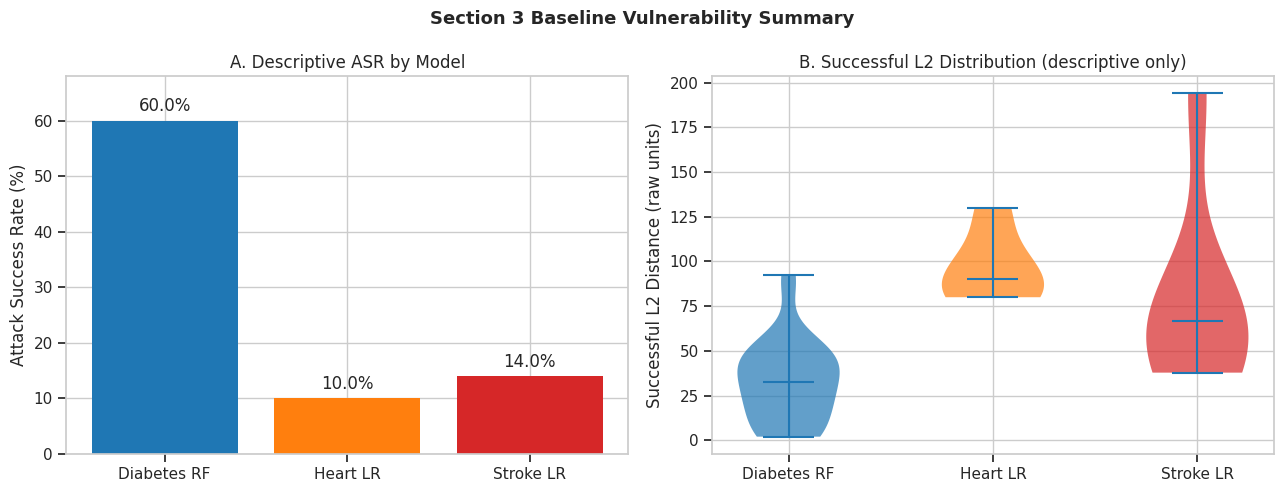

Saved figure -> /home/iaminspiredbro/my_projects/xai-health-risk-system/output/sec3_vulnerability_baseline_dashboard.png


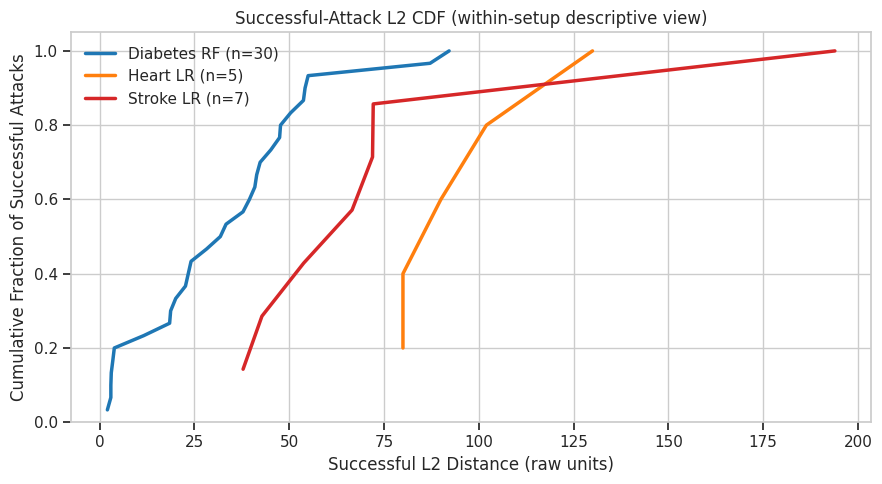

Saved figure -> /home/iaminspiredbro/my_projects/xai-health-risk-system/output/sec3_successful_l2_cdf.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

asr_vals = [metrics[d]['asr'] for d in DISEASES]
bars = axes[0].bar(
    [DISPLAY_NAMES[d] for d in DISEASES],
    asr_vals,
    color=[PALETTE[d] for d in DISEASES],
)
for bar, value in zip(bars, asr_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 1.0, f'{value:.1f}%', ha='center', va='bottom')
axes[0].set_ylabel('Attack Success Rate (%)')
axes[0].set_title('A. Descriptive ASR by Model')
axes[0].set_ylim(0, max(65, max(asr_vals) + 8))

violin_data = [metrics[d]['l2_vals'] for d in DISEASES if len(metrics[d]['l2_vals']) > 0]
violin_labels = [DISPLAY_NAMES[d] for d in DISEASES if len(metrics[d]['l2_vals']) > 0]
violin_colors = [PALETTE[d] for d in DISEASES if len(metrics[d]['l2_vals']) > 0]

if violin_data:
    vp = axes[1].violinplot(violin_data, positions=np.arange(len(violin_data)), showmedians=True, showextrema=True)
    for body, color in zip(vp['bodies'], violin_colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    axes[1].set_xticks(np.arange(len(violin_labels)))
    axes[1].set_xticklabels(violin_labels)
axes[1].set_ylabel('Successful L2 Distance (raw units)')
axes[1].set_title('B. Successful L2 Distribution (descriptive only)')

plt.suptitle('Section 3 Baseline Vulnerability Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sec3_vulnerability_baseline_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figure -> {OUTPUT_DIR / "sec3_vulnerability_baseline_dashboard.png"}')

fig, ax = plt.subplots(figsize=(9, 5))
for disease in DISEASES:
    vals = np.sort(metrics[disease]['l2_vals'])
    if len(vals) == 0:
        continue
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, linewidth=2.5, color=PALETTE[disease], label=f'{DISPLAY_NAMES[disease]} (n={len(vals)})')

ax.set_xlabel('Successful L2 Distance (raw units)')
ax.set_ylabel('Cumulative Fraction of Successful Attacks')
ax.set_title('Successful-Attack L2 CDF (within-setup descriptive view)')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sec3_successful_l2_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figure -> {OUTPUT_DIR / "sec3_successful_l2_cdf.png"}')


---
## 3.5 - Save Baseline Report

In [6]:
baseline_report = {
    'notes': [
        'Cross-disease ASR differences are descriptive because the attack methods differ.',
        'Successful L2 values are stored in raw feature units and should not be treated as directly comparable across diseases.',
        'Heart vs Stroke is retained as a descriptive LR contrast, not a causal regularisation ablation.',
    ],
    'core_metrics': {
        disease: {
            'attack_method': artifacts[disease]['attack_method'],
            'n_total': int(metrics[disease]['n_total']),
            'n_success': int(metrics[disease]['n_success']),
            'asr': round(float(metrics[disease]['asr']), 4),
            'l2_mean': round(float(metrics[disease]['l2_mean']), 6) if not np.isnan(metrics[disease]['l2_mean']) else None,
            'l2_median': round(float(metrics[disease]['l2_median']), 6) if not np.isnan(metrics[disease]['l2_median']) else None,
            'l2_std': round(float(metrics[disease]['l2_std']), 6) if not np.isnan(metrics[disease]['l2_std']) else None,
            'l2_iqr': round(float(metrics[disease]['l2_iqr']), 6) if not np.isnan(metrics[disease]['l2_iqr']) else None,
        }
        for disease in DISEASES
    },
    'lr_structure_summary': {
        'heart': heart_coef_summary,
        'stroke': stroke_coef_summary,
    },
    'feature_movement_top5': {
        'diabetes': diabetes_feat_df.head(5).replace({np.nan: None}).to_dict(orient='records'),
        'heart': heart_feat_df.head(5).replace({np.nan: None}).to_dict(orient='records'),
        'stroke': stroke_feat_df.head(5).replace({np.nan: None}).to_dict(orient='records'),
    },
    'numeric_bound_hit_diagnostics': {
        'heart': heart_bounds_df.replace({np.nan: None}).to_dict(orient='records'),
        'stroke': stroke_bounds_df.replace({np.nan: None}).to_dict(orient='records'),
    },
}

with open(OUTPUT_DIR / 'vulnerability_report.json', 'w') as f:
    json.dump(baseline_report, f, indent=2)

print(f'Saved report -> {OUTPUT_DIR / "vulnerability_report.json"}')
print('This report is suitable as a Section 4 baseline, with interpretation caveats included in the payload.')


Saved report -> /home/iaminspiredbro/my_projects/xai-health-risk-system/output/vulnerability_report.json
This report is suitable as a Section 4 baseline, with interpretation caveats included in the payload.


---
## 3.6 - Section Summary

In [7]:
print('=' * 72)
print('SECTION 3 SUMMARY - SAFER VULNERABILITY BASELINE')
print('=' * 72)

for disease in DISEASES:
    m = metrics[disease]
    print(f'\n{DISPLAY_NAMES[disease]}')
    print(f'  Attack method      : {artifacts[disease]["attack_method"]}')
    print(f'  ASR                : {m["asr"]:.1f}% ({m["n_success"]}/{m["n_total"]} flipped)')
    print(f'  Mean successful L2 : {m["l2_mean"]:.4f}' if not np.isnan(m['l2_mean']) else '  Mean successful L2 : n/a')

print('\nKey cautions:')
print('- Do not read cross-disease L2 values as unit-normalised robustness scores.')
print('- Do not interpret Heart vs Stroke here as a clean causal regularisation experiment.')
print('- Use this notebook as a descriptive baseline for Section 4 defence evaluation.')

print('\nSaved outputs:')
print(f'- {OUTPUT_DIR / "vulnerability_report.json"}')
print(f'- {OUTPUT_DIR / "sec3_vulnerability_baseline_dashboard.png"}')
print(f'- {OUTPUT_DIR / "sec3_successful_l2_cdf.png"}')


SECTION 3 SUMMARY - SAFER VULNERABILITY BASELINE

Diabetes RF
  Attack method      : HopSkipJump + raw-space clinical projection
  ASR                : 60.0% (30/50 flipped)
  Mean successful L2 : 32.8574

Heart LR
  Attack method      : Greedy constrained attack in raw clinical space
  ASR                : 10.0% (5/50 flipped)
  Mean successful L2 : 96.4063

Stroke LR
  Attack method      : Greedy constrained attack in raw clinical space
  ASR                : 14.0% (7/50 flipped)
  Mean successful L2 : 77.0185

Key cautions:
- Do not read cross-disease L2 values as unit-normalised robustness scores.
- Do not interpret Heart vs Stroke here as a clean causal regularisation experiment.
- Use this notebook as a descriptive baseline for Section 4 defence evaluation.

Saved outputs:
- /home/iaminspiredbro/my_projects/xai-health-risk-system/output/vulnerability_report.json
- /home/iaminspiredbro/my_projects/xai-health-risk-system/output/sec3_vulnerability_baseline_dashboard.png
- /home/iami